# RER Misclassification Analysis

Analyze failure cases of RER-based classification from trained self-supervised autoencoders.
Works for both **feature-based** (DINO/CLIP) and **convolutional** (raw images) setups.

In [40]:
## Configuration
# Set these paths to your trained model checkpoint and experiment config
# BASE_PATH="/home/thallybu/workspace/26ICDAR-RERC/1/6eb531df143545e08fbd69897b9b555d"
CHECKPOINT_PATH = f"/home/thallybu/mlartifacts/54/fbf2d66c2c3e48eeaeec053e75ff0206/artifacts/epoch=99-step=10000/epoch=99-step=10000.ckpt"
CONFIG_PATH = f"notebooks/error_analysis_emnist_balanced_conv.yaml"
SPLIT = "val"  # "val" or "test"
DEVICE = "cuda"  # "cuda" or "cpu"

# Number of example images to show per confused pair
N_EXAMPLES = 5
# Number of top confused pairs to analyze
N_TOP_PAIRS = 5
# Class index for per-class deep dive (set after seeing results, or None for auto)
DEEP_DIVE_CLASS = None

In [41]:
## Imports and setup
import sys, os, yaml
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
from collections import Counter

import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# Project imports
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src"))
from task.SelfSupervisedAETask import SelfSupervisedAETask
from util.rer_metrics import compute_rer, compute_class_chi, compute_dataset_chi, compute_rer_statistics
from data.CachedFeatureDatamodule import CachedFeatureDatamodule
from data.TorchvisionDatamodule import TorchvisionDatamodule

# --- Publication-ready plotly style (matplotlib / pgfplots look) ---
PUB_FONT = dict(family="Computer Modern, CMU Serif, Times New Roman, serif", size=12, color="black")

pio.templates["pub"] = go.layout.Template(
    layout=dict(
        font=PUB_FONT,
        paper_bgcolor="white",
        plot_bgcolor="white",
        colorway=[
            "#1f77b4", "#d62728", "#2ca02c", "#ff7f0e",
            "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
            "#bcbd22", "#17becf",
        ],
        xaxis=dict(
            showline=True, linewidth=1, linecolor="black", mirror=True,
            ticks="outside", tickwidth=1, tickcolor="black", ticklen=4,
            showgrid=False, zeroline=False, automargin=True,
        ),
        yaxis=dict(
            showline=True, linewidth=1, linecolor="black", mirror=True,
            ticks="outside", tickwidth=1, tickcolor="black", ticklen=4,
            showgrid=False, zeroline=False, automargin=True,
        ),
        legend=dict(
            bgcolor="rgba(255,255,255,0.9)",
            bordercolor="black", borderwidth=1,
        ),
        margin=dict(l=60, r=20, t=50, b=55),
    )
)
pio.templates.default = "pub"

# SVG export config — click the camera icon in the toolbar to save as SVG
PLOTLY_CONFIG = {
    "toImageButtonOptions": {
        "format": "svg",
        "filename": "figure",
        "scale": 1,
    },
    "displaylogo": False,
    "modeBarButtonsToRemove": ["lasso2d", "select2d"],
}

# Matplotlib-like sequential colorscales (ColorBrewer)
BLUES = [
    [0.0, "#f7fbff"], [0.125, "#deebf7"], [0.25, "#c6dbef"],
    [0.375, "#9ecae1"], [0.5, "#6baed6"], [0.625, "#4292c6"],
    [0.75, "#2171b5"], [0.875, "#08519c"], [1.0, "#08306b"],
]
REDS = [
    [0.0, "#fff5f0"], [0.125, "#fee0d2"], [0.25, "#fcbba1"],
    [0.375, "#fc9272"], [0.5, "#fb6a4a"], [0.625, "#ef3b2c"],
    [0.75, "#cb181d"], [0.875, "#a50f15"], [1.0, "#67000d"],
]
YLORRD = [
    [0.0, "#ffffcc"], [0.25, "#ffeda0"], [0.5, "#feb24c"],
    [0.75, "#fc4e2a"], [1.0, "#b10026"],
]

print("Imports OK")


Imports OK


## Load Model & Data

In [42]:
# Parse config to detect scenario
project_root = Path(os.getcwd()).parent
config_path = project_root / CONFIG_PATH
with open(config_path) as f:
    cfg = yaml.safe_load(f)

model_cfg = cfg["model"]["init_args"]
data_cfg = cfg["data"]["init_args"]
data_class = cfg["data"]["class_path"]

# Detect scenario
is_conv = model_cfg.get("autoencoder_class", "ShallowAutoencoder") == "ShallowConvAutoencoder"
is_feature_based = "CachedFeature" in data_class
image_shape = tuple(model_cfg.get("autoencoder_kwargs", {}).get("image_shape", [1, 28, 28])) if is_conv else None
num_classes = model_cfg["num_classes"]

print(f"Scenario: {'Convolutional (raw images)' if is_conv else 'Feature-based'}")
print(f"Num classes: {num_classes}")
if is_conv:
    print(f"Image shape: {image_shape}")

# Load model from checkpoint
model = SelfSupervisedAETask.load_from_checkpoint(CHECKPOINT_PATH, map_location=DEVICE)
model.eval()
model.to(DEVICE)
print(f"Model loaded from {CHECKPOINT_PATH}")

# Load data module
if is_feature_based:
    dm = CachedFeatureDatamodule(**data_cfg)
else:
    dm = TorchvisionDatamodule(**data_cfg)

dm.setup("fit" if SPLIT == "val" else "test")
dataloader = dm.val_dataloader() if SPLIT == "val" else dm.test_dataloader()
print(f"Data loaded: {SPLIT} split, {len(dataloader.dataset)} samples")

# For feature-based models, also load original images for visualization
images_dataset = None
if is_feature_based:
    # Infer original dataset from cache name
    ds_name = data_cfg["dataset_name"]  # e.g. "emnist_balanced_dinov2_vits14"
    # Detect dataset and params
    if "emnist" in ds_name.lower():
        _ds_name = "EMNIST"
        _split = "balanced" if "balanced" in ds_name else "digits" if "digits" in ds_name else "letters"
        _root = "/data/thallybu/datasets/EMNIST"
    elif "mnist" in ds_name.lower() and "fashion" not in ds_name.lower():
        _ds_name = "MNIST"
        _split = "digits"
        _root = "/data/thallybu/datasets"
    elif "fashion" in ds_name.lower():
        _ds_name = "FashionMNIST"
        _split = "digits"
        _root = "/data/thallybu/datasets"
    elif "cifar100" in ds_name.lower():
        _ds_name = "CIFAR100"
        _split = None
        _root = "/data/thallybu/datasets"
    elif "cifar" in ds_name.lower():
        _ds_name = "CIFAR10"
        _split = None
        _root = "/data/thallybu/datasets"
    else:
        _ds_name = "MNIST"
        _split = "digits"
        _root = "/data/thallybu/datasets"

    img_dm = TorchvisionDatamodule(
        dataset_name=_ds_name,
        root_dir=_root,
        emnist_split=_split if _ds_name == "EMNIST" else "digits",
        img_mode="L",
        batch_size=1,
        num_workers=0,
        seed=data_cfg.get("seed", 42),
        train_val_split=tuple(data_cfg.get("train_val_split", [0.9, 0.1])),
        raw_pixels=True,
        flatten=False,
    )
    img_dm.setup("fit" if SPLIT == "val" else "test")
    images_dataset = img_dm.val_dataset if SPLIT == "val" else img_dm.test_dataset
    print(f"Image dataset loaded for visualization: {_ds_name} ({len(images_dataset)} samples)")

# Build class label names
class_names = None
if "emnist" in cfg["data"].get("init_args", {}).get("dataset_name", "").lower() or \
   (not is_feature_based and data_cfg.get("dataset_name") == "EMNIST"):
    # EMNIST balanced: 0-9 digits, then uppercase, then lowercase subset
    from torchvision.datasets import EMNIST
    _split = data_cfg.get("emnist_split", "balanced") if not is_feature_based else _split
    _tmp = EMNIST(root="/data/thallybu/datasets/EMNIST", split=_split, download=False)
    if hasattr(_tmp, "classes"):
        class_names = _tmp.classes
    else:
        # Fallback: build from class_to_idx or manually
        import string
        if num_classes == 47:
            class_names = list(string.digits) + list(string.ascii_uppercase) + list(string.ascii_lowercase[:11])
        elif num_classes == 10:
            class_names = list(string.digits)
        elif num_classes == 26:
            class_names = list(string.ascii_uppercase)

if class_names is None:
    class_names = [str(i) for i in range(num_classes)]

print(f"Class names ({len(class_names)}): {class_names[:10]}{'...' if len(class_names) > 10 else ''}")

Scenario: Convolutional (raw images)
Num classes: 47
Image shape: (1, 28, 28)


/data/thallybu/packages/envs/mlresearch/lib/python3.11/site-packages/lightning/pytorch/utilities/migration/utils.py:56: PossibleUserWarning:

The loaded checkpoint was produced with Lightning v2.6.1, which is newer than your current Lightning version: v2.6.0



Model loaded from /home/thallybu/mlartifacts/54/fbf2d66c2c3e48eeaeec053e75ff0206/artifacts/epoch=99-step=10000/epoch=99-step=10000.ckpt
Data loaded: val split, 11280 samples
Class names (47): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']...


## Run Evaluation

In [43]:
# Collect all reconstruction errors, labels, and sample IDs
all_errors_list = []
all_labels_list = []
all_ids_list = []
all_features_list = []

with torch.no_grad():
    for batch in dataloader:
        features, labels, sample_ids = batch
        features = features.to(DEVICE)

        errors = model.ae_manager.compute_all_reconstruction_errors(features)
        all_errors_list.append(errors.cpu())
        all_labels_list.append(labels)
        all_ids_list.append(sample_ids)
        all_features_list.append(features.cpu())

all_errors = torch.cat(all_errors_list, dim=0)     # [N, K]
true_labels = torch.cat(all_labels_list, dim=0)     # [N]
sample_ids = torch.cat(all_ids_list, dim=0)          # [N]
all_features = torch.cat(all_features_list, dim=0)   # [N, D]
N = all_errors.shape[0]

# Predictions: class with minimum reconstruction error
predictions = all_errors.argmin(dim=1)

# 2nd best: mask the best class, then argmin again
errors_masked = all_errors.clone()
errors_masked[torch.arange(N), predictions] = float("inf")
second_best = errors_masked.argmin(dim=1)

# RER values (using true labels as reference)
rer_values = compute_rer(all_errors, true_labels)

# Confidence margin: error gap between best and 2nd best
best_errors = all_errors[torch.arange(N), predictions]
second_errors = all_errors[torch.arange(N), second_best]
margin = (second_errors - best_errors).abs()

# Own-class error and predicted-class error
own_class_errors = all_errors[torch.arange(N), true_labels.long()]
pred_class_errors = best_errors

# Build DataFrame
df = pd.DataFrame({
    "sample_id": sample_ids.numpy(),
    "true_label": true_labels.numpy().astype(int),
    "predicted": predictions.numpy().astype(int),
    "second_best": second_best.numpy().astype(int),
    "rer": rer_values.numpy(),
    "own_class_error": own_class_errors.numpy(),
    "pred_class_error": pred_class_errors.numpy(),
    "margin": margin.numpy(),
    "correct": (predictions == true_labels).numpy(),
})

# Add class name columns
df["true_name"] = df["true_label"].map(lambda x: class_names[x] if x < len(class_names) else str(x))
df["pred_name"] = df["predicted"].map(lambda x: class_names[x] if x < len(class_names) else str(x))
df["second_name"] = df["second_best"].map(lambda x: class_names[x] if x < len(class_names) else str(x))

print(f"Evaluation complete: {N} samples")
print(f"Correct: {df['correct'].sum()} ({df['correct'].mean()*100:.1f}%)")
print(f"Misclassified: {(~df['correct']).sum()} ({(~df['correct']).mean()*100:.1f}%)")
df.head(10)

Evaluation complete: 11280 samples
Correct: 7655 (67.9%)
Misclassified: 3625 (32.1%)


,sample_id,true_label,predicted,second_best,rer,own_class_error,pred_class_error,margin,correct,true_name,pred_name,second_name
0,109758,1,21,46,7.586035,0.006949,0.000916,0.001130,False,1,L,t
1,11022,41,41,11,0.926596,0.041114,0.041114,0.003257,True,g,g,B
2,65910,19,19,3,0.742993,0.012726,0.012726,0.004402,True,J,J,3
3,84130,28,5,28,1.390265,0.004642,0.003339,0.001303,False,S,5,S
4,43643,6,6,37,0.938330,0.007674,0.007674,0.000504,True,6,6,b
5,74203,34,34,33,0.732839,0.005224,0.005224,0.001904,True,Y,Y,X
6,74222,26,26,0,0.429152,0.021604,0.021604,0.028736,True,Q,Q,0
7,64596,5,5,11,0.782749,0.014814,0.014814,0.004112,True,5,5,B
8,32018,34,33,18,3.492831,0.025410,0.007275,0.001882,False,Y,X,I
9,72096,7,7,19,0.307724,0.003764,0.003764,0.008468,True,7,7,J


## Overall Metrics Summary

In [44]:
# Classification metrics
acc = accuracy_score(df["true_label"], df["predicted"])
f1_mi = f1_score(df["true_label"], df["predicted"], average="micro")
f1_ma = f1_score(df["true_label"], df["predicted"], average="macro")

# RER statistics
rer_stats = compute_rer_statistics(rer_values, true_labels)

summary = pd.DataFrame({
    "Metric": [
        "Accuracy", "F1 (micro)", "F1 (macro)",
        "Chi (dataset)", "RER mean", "RER std", "RER median",
        "RER min", "RER max", "Frac RER > 1.0",
        "Hardest class", "Easiest class",
    ],
    "Value": [
        f"{acc:.4f}", f"{f1_mi:.4f}", f"{f1_ma:.4f}",
        f"{rer_stats['chi']:.4f}", f"{rer_stats['rer_mean']:.4f}",
        f"{rer_stats['rer_std']:.4f}", f"{rer_stats['rer_median']:.4f}",
        f"{rer_stats['rer_min']:.4f}", f"{rer_stats['rer_max']:.4f}",
        f"{rer_stats['frac_above_1']:.4f}",
        f"{class_names[rer_stats['hardest_class']]} (chi={rer_stats['hardest_class_chi']:.3f})",
        f"{class_names[rer_stats['easiest_class']]} (chi={rer_stats['easiest_class_chi']:.3f})",
    ]
})
display(summary.style.hide(axis="index"))

Metric,Value
Accuracy,0.6786
F1 (micro),0.6786
F1 (macro),0.6738
Chi (dataset),1.3861
RER mean,1.3861
RER std,2.3663
RER median,0.6673
RER min,0.0963
RER max,38.9784
Frac RER > 1.0,0.3214


## Confusion Matrix

In [45]:
# Compute confusion matrices
cm = confusion_matrix(df["true_label"], df["predicted"], labels=range(num_classes))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Confusion Matrix (counts)", "Confusion Matrix (row-normalized)"),
    horizontal_spacing=0.15,
)

fig.add_trace(
    go.Heatmap(
        z=cm, x=class_names, y=class_names,
        colorscale=BLUES,
        colorbar=dict(title="count", x=0.44, len=0.9, thickness=12, outlinewidth=1, outlinecolor="black"),
        hovertemplate="true=%{y}<br>pred=%{x}<br>count=%{z}<extra></extra>",
    ),
    row=1, col=1,
)
fig.add_trace(
    go.Heatmap(
        z=cm_norm, x=class_names, y=class_names,
        colorscale=REDS, zmin=0, zmax=1,
        colorbar=dict(title="rate", x=1.0, len=0.9, thickness=12, outlinewidth=1, outlinecolor="black"),
        hovertemplate="true=%{y}<br>pred=%{x}<br>rate=%{z:.3f}<extra></extra>",
    ),
    row=1, col=2,
)

for col in (1, 2):
    fig.update_xaxes(title_text="Predicted", dtick=1, tickangle=-90, row=1, col=col, scaleanchor=f"y{'' if col==1 else '2'}", constrain="domain")
    fig.update_yaxes(title_text="True", dtick=1, autorange="reversed", row=1, col=col)

side = max(420, num_classes * 22)
fig.update_layout(width=side * 2 + 180, height=side + 80, showlegend=False)
fig.show(config=PLOTLY_CONFIG)


## Cross-Reconstruction of Prototypes

For each class *i*, reconstruct its prototypes through **every** autoencoder *j*.
This produces a cross-reconstruction error matrix that reveals which AEs find each
other's prototypes easy to reconstruct — a structural predictor of misclassification.

In [46]:
# --- Cross-reconstruction error matrix for prototypes ---
proto_features = model._prototype_features
proto_classes = model._prototype_classes

if proto_features is None or len(proto_features) == 0:
    print("No prototype features found in the model checkpoint.")
else:
    cross_errors = np.zeros((num_classes, num_classes))
    proto_counts = np.zeros(num_classes)

    with torch.no_grad():
        for i in range(len(proto_features)):
            c_true = int(proto_classes[i].item())
            feat = proto_features[i].unsqueeze(0).to(DEVICE)
            errors = model.ae_manager.compute_all_reconstruction_errors(feat)
            cross_errors[c_true] += errors.cpu().numpy().squeeze(0)
            proto_counts[c_true] += 1

    for c in range(num_classes):
        if proto_counts[c] > 0:
            cross_errors[c] /= proto_counts[c]

    cross_offdiag = cross_errors.copy()
    np.fill_diagonal(cross_offdiag, np.nan)

    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=(
            "Cross-Recon Error (AE_j on protos of class i)",
            "Cross-Recon Error (off-diagonal)",
            "Confusion Matrix (row-normalized)",
        ),
        horizontal_spacing=0.10,
    )

    fig.add_trace(go.Heatmap(
        z=cross_errors, x=class_names, y=class_names,
        colorscale=YLORRD,
        colorbar=dict(x=0.285, len=0.9, thickness=10, outlinewidth=1, outlinecolor="black"),
        hovertemplate="i=%{y}<br>j=%{x}<br>err=%{z:.4f}<extra></extra>",
    ), row=1, col=1)

    fig.add_trace(go.Heatmap(
        z=cross_offdiag, x=class_names, y=class_names,
        colorscale=YLORRD,
        colorbar=dict(x=0.645, len=0.9, thickness=10, outlinewidth=1, outlinecolor="black"),
        hovertemplate="i=%{y}<br>j=%{x}<br>err=%{z:.4f}<extra></extra>",
    ), row=1, col=2)

    fig.add_trace(go.Heatmap(
        z=cm_norm, x=class_names, y=class_names,
        colorscale=REDS, zmin=0, zmax=1,
        colorbar=dict(x=1.0, len=0.9, thickness=10, outlinewidth=1, outlinecolor="black"),
        hovertemplate="true=%{y}<br>pred=%{x}<br>rate=%{z:.3f}<extra></extra>",
    ), row=1, col=3)

    for col in (1, 2, 3):
        fig.update_xaxes(dtick=1, tickangle=-90, row=1, col=col)
        fig.update_yaxes(dtick=1, autorange="reversed", row=1, col=col)

    fig.update_xaxes(title_text="Reconstructing AE (j)", row=1, col=1)
    fig.update_yaxes(title_text="Prototype class (i)", row=1, col=1)
    fig.update_xaxes(title_text="Reconstructing AE (j)", row=1, col=2)
    fig.update_xaxes(title_text="Predicted", row=1, col=3)
    fig.update_yaxes(title_text="True", row=1, col=3)

    side = max(380, num_classes * 20)
    fig.update_layout(width=side * 3 + 220, height=side + 90, showlegend=False)
    fig.show(config=PLOTLY_CONFIG)

    # --- Correlation: off-diagonal cross-recon error vs confusion rate ---
    offdiag_mask = ~np.eye(num_classes, dtype=bool)
    cross_vals = cross_errors[offdiag_mask]
    cm_vals = cm_norm[offdiag_mask]
    cross_affinity = 1.0 / np.clip(cross_vals, 1e-8, None)

    from scipy.stats import spearmanr, pearsonr
    r_pearson, p_pearson = pearsonr(cross_affinity, cm_vals)
    r_spearman, p_spearman = spearmanr(cross_affinity, cm_vals)
    r2_pearson, p2 = pearsonr(cross_vals, cm_vals)
    r2_spearman, p2s = spearmanr(cross_vals, cm_vals)

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(
            f"Affinity vs Confusion — Pearson r={r_pearson:.3f}, Spearman ρ={r_spearman:.3f}",
            f"Error vs Confusion — Pearson r={r2_pearson:.3f}, Spearman ρ={r2_spearman:.3f}",
        ),
        horizontal_spacing=0.12,
    )
    fig.add_trace(go.Scatter(
        x=cross_affinity, y=cm_vals, mode="markers",
        marker=dict(size=5, color="#4292c6", opacity=0.45, line=dict(width=0)),
        showlegend=False,
    ), row=1, col=1)
    fig.add_trace(go.Scatter(
        x=cross_vals, y=cm_vals, mode="markers",
        marker=dict(size=5, color="#ef3b2c", opacity=0.45, line=dict(width=0)),
        showlegend=False,
    ), row=1, col=2)

    fig.update_xaxes(title_text="Prototype cross-recon affinity (1 / error)", row=1, col=1)
    fig.update_yaxes(title_text="Confusion rate (cm_norm[i,j])", row=1, col=1)
    fig.update_xaxes(title_text="Prototype cross-recon error (MSE)", row=1, col=2)
    fig.update_yaxes(title_text="Confusion rate (cm_norm[i,j])", row=1, col=2)
    fig.update_layout(width=1000, height=440)
    fig.show(config=PLOTLY_CONFIG)

    # --- Per-class top "leaky" AEs ---
    print("Per-class: AEs that reconstruct class_i prototypes best (excluding own AE)")
    print("=" * 80)
    rows = []
    for c in range(num_classes):
        own_err = cross_errors[c, c]
        other_errs = sorted([(j, cross_errors[c, j]) for j in range(num_classes) if j != c], key=lambda x: x[1])[:3]
        top3_info = [
            f"{class_names[j]} (err={err:.4f}, conf={cm_norm[c, j]:.3f})"
            for j, err in other_errs
        ]
        rows.append({
            "class": class_names[c],
            "own_recon_err": f"{own_err:.4f}",
            "top_cross_recon": " | ".join(top3_info),
        })
    df_cross = pd.DataFrame(rows)
    display(df_cross)


Per-class: AEs that reconstruct class_i prototypes best (excluding own AE)


,class,own_recon_err,top_cross_recon
0,0,0.0046,"O (err=0.0101, conf=0.183) | C (err=0.0169, co..."
1,1,0.0010,"t (err=0.0050, conf=0.008) | J (err=0.0061, co..."
2,2,0.0067,"Z (err=0.0490, conf=0.287) | 3 (err=0.0521, co..."
3,3,0.0053,"B (err=0.0336, conf=0.008) | g (err=0.0378, co..."
4,4,0.0051,"g (err=0.0304, conf=0.009) | H (err=0.0331, co..."
5,5,0.0072,"S (err=0.0279, conf=0.564) | g (err=0.0467, co..."
6,6,0.0046,"G (err=0.0183, conf=0.031) | h (err=0.0311, co..."
7,7,0.0031,"J (err=0.0230, conf=0.000) | g (err=0.0317, co..."
8,8,0.0071,"R (err=0.0372, conf=0.008) | 9 (err=0.0405, co..."
9,9,0.0051,"g (err=0.0115, conf=0.258) | q (err=0.0138, co..."


## Per-Class RER Distribution & Accuracy

In [47]:
# Per-class chi and accuracy
class_chi = compute_class_chi(rer_values, true_labels)
per_class = []
for c in range(num_classes):
    mask = df["true_label"] == c
    n_total = mask.sum()
    n_correct = (df.loc[mask, "correct"]).sum()
    per_class.append({
        "class": c,
        "name": class_names[c],
        "chi": class_chi.get(c, 0.0),
        "accuracy": n_correct / max(n_total, 1),
        "n_samples": n_total,
        "n_errors": n_total - n_correct,
    })
df_class = pd.DataFrame(per_class).sort_values("chi", ascending=False)

order_names = [class_names[c] for c in df_class["class"].values]
chi_vals = df_class["chi"].values
acc_vals = df_class["accuracy"].values

# Red->Yellow->Green reversed: high chi = red
def chi_color(v, vmin, vmax):
    t = 0.0 if vmax == vmin else (v - vmin) / (vmax - vmin)
    # interp red->green reversed: red for high
    r = int(215 * t + 26 * (1 - t))
    g = int(48 * t + 152 * (1 - t))
    b = int(39 * t + 80 * (1 - t))
    return f"rgb({r},{g},{b})"

chi_colors = [chi_color(v, chi_vals.min(), chi_vals.max()) for v in chi_vals]
acc_colors = ["#d32f2f" if a < 0.5 else "#ff9800" if a < 0.8 else "#4caf50" for a in acc_vals]

fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.12,
    subplot_titles=("Per-Class Difficulty (Chi) — sorted hardest to easiest", "Per-Class Accuracy (same order)"),
)
fig.add_trace(go.Bar(
    x=order_names, y=chi_vals, marker_color=chi_colors, marker_line_color="black", marker_line_width=0.5,
    name="chi", showlegend=False,
), row=1, col=1)
fig.add_hline(y=1.0, line_dash="dash", line_color="red", line_width=1, row=1, col=1,
              annotation_text="RER=1.0", annotation_position="top right")

fig.add_trace(go.Bar(
    x=order_names, y=acc_vals, marker_color=acc_colors, marker_line_color="black", marker_line_width=0.5,
    name="accuracy", showlegend=False,
), row=2, col=1)

fig.update_xaxes(tickangle=-90, row=2, col=1)
fig.update_yaxes(title_text="Chi (mean RER)", row=1, col=1)
fig.update_yaxes(title_text="Accuracy", range=[0, 1.05], row=2, col=1)
fig.update_layout(width=max(720, num_classes * 22), height=640)
fig.show(config=PLOTLY_CONFIG)

print("Top 10 hardest classes:")
display(df_class.head(10)[["name", "chi", "accuracy", "n_samples", "n_errors"]])


Top 10 hardest classes:


,name,chi,accuracy,n_samples,n_errors
21,L,6.422757,0.238095,252,192
18,I,6.115018,0.105991,217,194
42,h,3.853032,0.322097,267,181
28,S,3.159505,0.144033,243,208
1,1,2.873412,0.575510,245,104
5,5,2.277688,0.408889,225,133
44,q,2.231341,0.256198,242,180
41,g,1.992876,0.391837,245,149
34,Y,1.974673,0.424242,231,133
37,b,1.894594,0.524229,227,108


## Most Confused Class Pairs

Top 5 most confused class pairs:


,pair,count,mean_rer,mean_margin
293,S -> 5,195,3.638131,0.012435
456,h -> b,155,5.940351,0.009907
237,O -> 0,153,1.827556,0.003182
44,5 -> S,127,3.549423,0.016679
471,q -> 9,109,2.744330,0.009061



2nd-best class for misclassified samples (top 15):


,true_name,pred_name,second_name,count
527,O,0,O,103
659,S,5,S,84
104,5,S,5,58
311,F,f,F,45
458,L,1,I,45
41,2,Z,2,44
179,9,g,9,43
653,S,5,3,40
364,I,1,I,40
1039,h,b,K,40


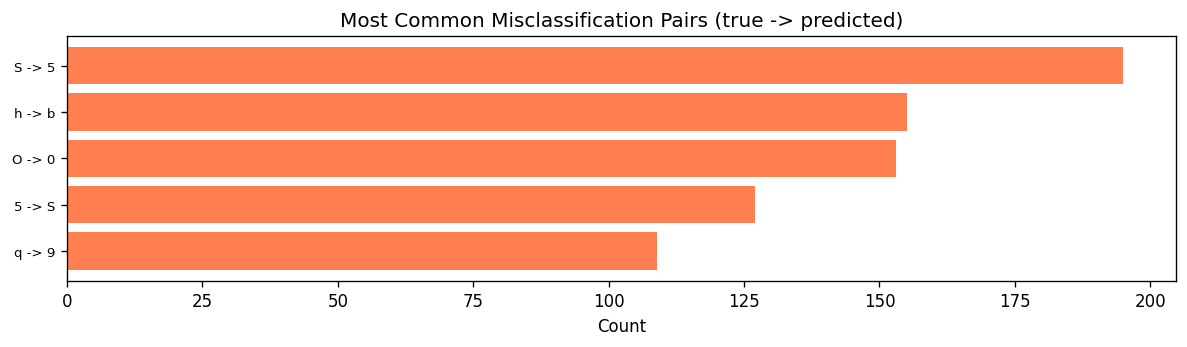

In [48]:
# Extract misclassified samples
df_wrong = df[~df["correct"]].copy()

# Top confused pairs (true -> predicted)
pair_counts = df_wrong.groupby(["true_label", "predicted"]).agg(
    count=("sample_id", "size"),
    mean_rer=("rer", "mean"),
    mean_margin=("margin", "mean"),
).reset_index().sort_values("count", ascending=False)

# Add class names
pair_counts["true_name"] = pair_counts["true_label"].map(lambda x: class_names[x])
pair_counts["pred_name"] = pair_counts["predicted"].map(lambda x: class_names[x])
pair_counts["pair"] = pair_counts["true_name"] + " -> " + pair_counts["pred_name"]

print(f"Top {N_TOP_PAIRS} most confused class pairs:")
display(pair_counts.head(N_TOP_PAIRS)[["pair", "count", "mean_rer", "mean_margin"]])

# 2nd-best class distribution for misclassified samples
print("\n2nd-best class for misclassified samples (top 15):")
second_best_counts = df_wrong.groupby(["true_name", "pred_name", "second_name"]).size().reset_index(name="count")
second_best_counts = second_best_counts.sort_values("count", ascending=False)
display(second_best_counts.head(15))

# Visualize top confused pairs
top_pairs = pair_counts.head(min(N_TOP_PAIRS, 20))
fig, ax = plt.subplots(figsize=(10, max(3, len(top_pairs) * 0.35)))
ax.barh(range(len(top_pairs)), top_pairs["count"].values, color="coral")
ax.set_yticks(range(len(top_pairs)))
ax.set_yticklabels(top_pairs["pair"].values, fontsize=8)
ax.set_xlabel("Count")
ax.set_title("Most Common Misclassification Pairs (true -> predicted)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Example Misclassifications\n\nFor each top confused pair, show example images with true label, predicted label, 2nd-best label, and RER value.\nFor convolutional models, also show reconstructions from the true-class and predicted-class autoencoders.

In [49]:
pair_counts

,true_label,predicted,count,mean_rer,mean_margin,true_name,pred_name,pair
293,28,5,195,3.638131,0.012435,S,5,S -> 5
456,42,37,155,5.940351,0.009907,h,b,h -> b
237,24,0,153,1.827556,0.003182,O,0,O -> 0
44,5,28,127,3.549423,0.016679,5,S,5 -> S
471,44,9,109,2.744330,0.009061,q,9,q -> 9
...,...,...,...,...,...,...,...,...
494,46,6,1,1.659083,0.002364,t,6,t -> 6
495,46,9,1,1.327778,0.000439,t,9,t -> 9
36,4,36,1,3.632186,0.006181,4,a,4 -> a
175,18,38,1,1.691235,0.012138,I,d,I -> d


In [53]:
def get_image(idx, df_row):
    """Get image tensor for a sample by its DataFrame index."""
    if is_conv:
        feat = all_features[idx]
        C, H, W = image_shape
        return feat.view(C, H, W)
    elif images_dataset is not None:
        img, label, _ = images_dataset[idx]
        return img
    return None

def tensor_to_np(img_tensor):
    if img_tensor is None:
        return None
    img = img_tensor.squeeze().cpu().numpy()
    if img.ndim == 3 and img.shape[0] in (1, 3):
        img = np.transpose(img, (1, 2, 0))
    if img.ndim == 3 and img.shape[2] == 1:
        img = img.squeeze(-1)
    return np.clip(img, 0, 1)

def add_image_trace(fig, img_np, row, col):
    """Add an image as a Heatmap trace (grayscale) or Image trace (RGB)."""
    if img_np is None:
        fig.add_annotation(text="N/A", xref=f"x{'' if row==1 and col==1 else (row-1)*fig._grid_ref_cols + col}",
                           row=row, col=col, showarrow=False)
        return
    if img_np.ndim == 2:
        fig.add_trace(go.Heatmap(
            z=img_np, colorscale="gray", showscale=False, zmin=0, zmax=1,
            hoverinfo="skip",
        ), row=row, col=col)
    else:
        fig.add_trace(go.Image(z=(img_np * 255).astype(np.uint8)), row=row, col=col)
    fig.update_xaxes(visible=False, row=row, col=col)
    fig.update_yaxes(visible=False, autorange="reversed", row=row, col=col, scaleanchor=None)

def get_reconstruction(features_tensor, class_idx):
    if not is_conv:
        return None
    with torch.no_grad():
        feat = features_tensor.unsqueeze(0).to(DEVICE)
        recon, _ = model.ae_manager.forward_class(feat, class_idx)
        C, H, W = image_shape
        return recon.cpu().squeeze(0).view(C, H, W)

n_pairs_to_show = min(N_TOP_PAIRS, 5)
for pair_idx in range(n_pairs_to_show):
    row = pair_counts.iloc[pair_idx]
    true_c, pred_c = int(row["true_label"]), int(row["predicted"])
    pair_name = row["pair"]

    mask = (df_wrong["true_label"] == true_c) & (df_wrong["predicted"] == pred_c)
    pair_samples = df_wrong[mask].sort_values("rer", ascending=False)
    n_show = min(N_EXAMPLES, len(pair_samples))
    if n_show == 0:
        continue

    n_cols = n_show
    n_rows = 3 if is_conv else 1
    row_labels = ["Original", "Recon (true)", "Recon (pred)"] if is_conv else ["Original"]

    subplot_titles = []
    samples_list = list(pair_samples.head(n_show).iterrows())
    # for ri in range(n_rows):
    #     for df_idx, sample in samples_list:
    #         if ri == 0:
    #             subplot_titles.append(
    #                 f"T:{sample['true_name']} P:{sample['pred_name']}<br>2nd:{sample['second_name']} RER:{sample['rer']:.3f}"
    #             )
    #         elif ri == 1:
    #             subplot_titles.append(f"Recon true err={sample['own_class_error']:.4f}")
    #         else:
    #             subplot_titles.append(f"Recon pred err={sample['pred_class_error']:.4f}")

    fig = make_subplots(
        rows=n_rows, cols=n_cols,
        subplot_titles=subplot_titles,
        horizontal_spacing=0.02, vertical_spacing=0.08,
    )

    for i, (df_idx, sample) in enumerate(samples_list):
        orig_idx = df.index.get_loc(df_idx)
        img = tensor_to_np(get_image(orig_idx, sample))
        add_image_trace(fig, img, row=1, col=i + 1)
        if is_conv:
            recon_true = tensor_to_np(get_reconstruction(all_features[orig_idx], true_c))
            add_image_trace(fig, recon_true, row=2, col=i + 1)
            recon_pred = tensor_to_np(get_reconstruction(all_features[orig_idx], pred_c))
            add_image_trace(fig, recon_pred, row=3, col=i + 1)

    for ann in fig["layout"]["annotations"]:
        ann["font"] = dict(size=9, family=PUB_FONT["family"])

    fig.update_layout(
        title=dict(
            text=f"<b>Pair: {pair_name}</b> (count={int(row['count'])}, mean RER={row['mean_rer']:.3f})",
            x=0.5, xanchor="center",
        ),
        width=n_cols * 170, height=n_rows * 190 + 60,
        margin=dict(l=10, r=10, t=80, b=10),
    )
    fig.show(config=PLOTLY_CONFIG)


## RER Distribution Analysis

In [51]:
# --- RER Distribution Analysis ---
rer_correct = df.loc[df["correct"], "rer"].values
rer_wrong = df.loc[~df["correct"], "rer"].values
x_max = float(min(df["rer"].quantile(0.99), 5.0))
bin_size = x_max / 60

sample_idx = np.random.choice(len(df), min(5000, len(df)), replace=False)
df_sample = df.iloc[sample_idx]

borderline = df[df["correct"] & (df["rer"] > 0.8)].sort_values("rer", ascending=False)
print(f"Borderline samples (correct but RER > 0.8): {len(borderline)}")

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=(
        "RER Distribution: Correct vs Misclassified",
        "RER vs Confidence Margin",
        f"Borderline: Correct but High RER (n={len(borderline)})",
    ),
    horizontal_spacing=0.10,
)

fig.add_trace(go.Histogram(
    x=rer_correct, name=f"Correct (n={len(rer_correct)})",
    marker_color="#2ca02c", opacity=0.55,
    xbins=dict(start=0, end=x_max, size=bin_size), histnorm="probability density",
    marker_line_color="#1a5e1a", marker_line_width=0.3,
), row=1, col=1)
fig.add_trace(go.Histogram(
    x=rer_wrong, name=f"Wrong (n={len(rer_wrong)})",
    marker_color="#d62728", opacity=0.55,
    xbins=dict(start=0, end=x_max, size=bin_size), histnorm="probability density",
    marker_line_color="#7a0e14", marker_line_width=0.3,
), row=1, col=1)
fig.add_vline(x=1.0, line_dash="dash", line_color="black", line_width=1, row=1, col=1)
fig.update_xaxes(title_text="RER", range=[0, x_max], row=1, col=1)
fig.update_yaxes(title_text="Density", row=1, col=1)

scatter_colors = ["#2ca02c" if c else "#d62728" for c in df_sample["correct"]]
fig.add_trace(go.Scatter(
    x=df_sample["rer"], y=df_sample["margin"], mode="markers",
    marker=dict(size=4, color=scatter_colors, opacity=0.35, line=dict(width=0)),
    showlegend=False, hoverinfo="skip",
), row=1, col=2)
fig.update_xaxes(title_text="RER", range=[0, x_max], row=1, col=2)
fig.update_yaxes(title_text="Margin (2nd - 1st)", row=1, col=2)

fig.add_trace(go.Histogram(
    x=borderline["rer"].values, marker_color="#ff7f0e", opacity=0.75,
    nbinsx=30, showlegend=False, marker_line_color="black", marker_line_width=0.3,
), row=1, col=3)
fig.update_xaxes(title_text="RER", row=1, col=3)
fig.update_yaxes(title_text="Count", row=1, col=3)

fig.update_layout(
    barmode="overlay",
    width=1400, height=460,
    legend=dict(x=0.22, y=0.98, xanchor="right"),
)
fig.show(config=PLOTLY_CONFIG)

if len(borderline) > 0:
    print("\nTop borderline samples (correct but uncertain):")
    display(borderline.head(10)[["true_name", "pred_name", "second_name", "rer", "margin", "own_class_error"]])


Borderline samples (correct but RER > 0.8): 1027



Top borderline samples (correct but uncertain):


,true_name,pred_name,second_name,rer,margin,own_class_error
1358,t,t,F,0.999856,0.000001,0.008297
7794,Z,Z,2,0.999842,0.000005,0.029379
10483,9,9,g,0.999739,0.000004,0.014915
9544,b,b,6,0.999726,0.000003,0.010115
11156,Q,Q,2,0.999409,0.000025,0.041900
2607,A,A,b,0.999045,0.000027,0.028153
2850,g,g,8,0.998497,0.000045,0.030227
5799,0,0,O,0.998449,0.000013,0.008210
6333,P,P,R,0.998333,0.000068,0.040792
3902,f,f,R,0.998149,0.000040,0.021529


## Per-Class Failure Deep Dive\n\nSet `DEEP_DIVE_CLASS` in the config cell to a specific class index, or leave as `None` to auto-select the worst class.

In [52]:
# Select class for deep dive
if DEEP_DIVE_CLASS is not None:
    dive_class = DEEP_DIVE_CLASS
else:
    dive_class = int(df_class.iloc[0]["class"])

dive_name = class_names[dive_class]
dive_mask = df["true_label"] == dive_class
df_dive = df[dive_mask]
df_dive_wrong = df_dive[~df_dive["correct"]]

n_total = len(df_dive)
n_wrong = len(df_dive_wrong)
dive_acc = df_dive["correct"].mean()

print(f"Deep dive: class {dive_class} = '{dive_name}'")
print(f"  Samples: {n_total}, Errors: {n_wrong}, Accuracy: {dive_acc:.3f}")
print(f"  Mean RER: {df_dive['rer'].mean():.4f}, Median RER: {df_dive['rer'].median():.4f}")

confused_with = None
if n_wrong > 0:
    confused_with = df_dive_wrong.groupby("predicted").agg(
        count=("sample_id", "size"),
        mean_rer=("rer", "mean"),
    ).sort_values("count", ascending=False)
    confused_with["pred_name"] = [class_names[c] for c in confused_with.index]
    confused_with["pct"] = confused_with["count"] / n_wrong * 100

    print(f"\n  Confused with (top 10):")
    display(confused_with.head(10)[["pred_name", "count", "pct", "mean_rer"]])

    second_counts = df_dive_wrong["second_name"].value_counts().head(10)
    print(f"\n  2nd-best class for misclassified '{dive_name}' samples:")
    display(second_counts.to_frame("count"))

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        f"RER Distribution for class '{dive_name}'",
        f"Where '{dive_name}' errors go" if n_wrong > 0 else f"'{dive_name}': perfect classification",
    ),
    horizontal_spacing=0.15,
)

rer_ok = df_dive.loc[df_dive["correct"], "rer"].values
fig.add_trace(go.Histogram(
    x=rer_ok, name="Correct", marker_color="#2ca02c", opacity=0.55,
    nbinsx=30, histnorm="probability density",
    marker_line_color="#1a5e1a", marker_line_width=0.3,
), row=1, col=1)
if n_wrong > 0:
    fig.add_trace(go.Histogram(
        x=df_dive_wrong["rer"].values, name="Wrong", marker_color="#d62728", opacity=0.55,
        nbinsx=30, histnorm="probability density",
        marker_line_color="#7a0e14", marker_line_width=0.3,
    ), row=1, col=1)
fig.add_vline(x=1.0, line_dash="dash", line_color="black", line_width=1, row=1, col=1)
fig.update_xaxes(title_text="RER", row=1, col=1)
fig.update_yaxes(title_text="Density", row=1, col=1)

if n_wrong > 0:
    top_confused = confused_with.head(8)
    other_count = n_wrong - top_confused["count"].sum()
    labels = list(top_confused["pred_name"].values)
    sizes = list(top_confused["count"].values)
    if other_count > 0:
        labels.append("other")
        sizes.append(other_count)
    fig.add_trace(go.Bar(
        x=sizes, y=labels, orientation="h",
        marker_color="#4292c6", marker_line_color="black", marker_line_width=0.5,
        showlegend=False,
    ), row=1, col=2)
    fig.update_xaxes(title_text="Count", row=1, col=2)
    fig.update_yaxes(autorange="reversed", row=1, col=2)

fig.update_layout(
    barmode="overlay", width=1150, height=440,
    legend=dict(x=0.42, y=0.98, xanchor="right"),
)
fig.show(config=PLOTLY_CONFIG)

# Show example misclassified images for this class
if n_wrong > 0:
    n_show = min(10, n_wrong)
    dive_samples = df_dive_wrong.sort_values("rer", ascending=False).head(n_show)
    n_rows = 3 if is_conv else 1

    samples_list = list(dive_samples.iterrows())
    subplot_titles = []
    for ri in range(n_rows):
        for df_idx, sample in samples_list:
            if ri == 0:
                subplot_titles.append(
                    f"P:{sample['pred_name']} 2nd:{sample['second_name']}<br>RER:{sample['rer']:.3f}"
                )
            elif ri == 1:
                subplot_titles.append(f"Recon true err={sample['own_class_error']:.4f}")
            else:
                subplot_titles.append(f"Recon pred err={sample['pred_class_error']:.4f}")

    fig = make_subplots(
        rows=n_rows, cols=n_show,
        subplot_titles=subplot_titles,
        horizontal_spacing=0.02, vertical_spacing=0.08,
    )

    for i, (df_idx, sample) in enumerate(samples_list):
        orig_idx = df.index.get_loc(df_idx)
        img = tensor_to_np(get_image(orig_idx, sample))
        add_image_trace(fig, img, row=1, col=i + 1)
        if is_conv:
            recon_true = tensor_to_np(get_reconstruction(all_features[orig_idx], dive_class))
            add_image_trace(fig, recon_true, row=2, col=i + 1)
            recon_pred = tensor_to_np(get_reconstruction(all_features[orig_idx], int(sample["predicted"])))
            add_image_trace(fig, recon_pred, row=3, col=i + 1)

    for ann in fig["layout"]["annotations"]:
        ann["font"] = dict(size=9, family=PUB_FONT["family"])

    fig.update_layout(
        title=dict(
            text=f"<b>Misclassified '{dive_name}' samples (sorted by RER, worst first)</b>",
            x=0.5, xanchor="center",
        ),
        width=n_show * 170, height=n_rows * 190 + 60,
        margin=dict(l=10, r=10, t=80, b=10),
    )
    fig.show(config=PLOTLY_CONFIG)


Deep dive: class 21 = 'L'
  Samples: 252, Errors: 192, Accuracy: 0.238
  Mean RER: 6.4228, Median RER: 4.4077

  Confused with (top 10):


,pred_name,count,pct,mean_rer
predicted,,,,
1,1,100,52.083333,8.563778
18,I,26,13.541667,11.850599
12,C,18,9.375000,10.482181
42,h,16,8.333333,5.751295
35,Z,10,5.208333,5.302813
46,t,7,3.645833,2.715905
20,K,7,3.645833,5.756882
2,2,3,1.562500,3.418134
6,6,1,0.520833,7.723812



  2nd-best class for misclassified 'L' samples:


,count
second_name,
I,47
t,23
L,22
6,19
1,14
V,11
Z,10
C,9
K,9
